# ***Gamma Correction*** 😘

In [3]:
# Import libraries
import cv2
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

# Import Image
# https://topaz.com.mt/wp-content/uploads/2016/01/Mdina-Sunset-1.jpg
img = cv2.imread("Mdina-Sunset.jpg", 1)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB) # type: ignore

## Power Law (Gamma) Correction

The power law is defined by the equation:
$$ s = C · r^ɣ  $$
Where:
 - s is the output pixel value
 - r is the input pixel value (normalised between 0 and 1)
 - C is a positive scaling constant, typically set to 1 for standard use
 - γ is the exponent that controls the shape of the transformation

In this code example:

```img_f = img.astype(np.float64)```

First converts the image's integer values into float in order to not lose any data in the conversion.

```(img_f / 255.0)```

Normalises the image with values between 0 and 1 in order to effectively make use of the 0 to 1 range in the exponential graph.

```(img_f / 255.0) ** gamma```

The actual power distribution is applied here in order to change the color distribution accordingly.

```c * 255.0 * (img_f / 255.0) ** gamma```

Firstly the result of the above is multiplied by 255 to scale the image's rgb values back to the range 0 to 255. Then the scaling constant c is applied.

```return np.clip(s, 0, 255).astype(np.uint8)```

Here the final result is put in the clip function to ensure the numbers are within the 0 to 255 range. This is just a measure to minimise bugs potentially occurring from rounding errors. Finally, the image's values are converted back to 8-bit integer.


In [4]:
def powerLaw(img, gamma, c=1.0):
	img_f = img.astype(np.float64)
	s = c * 255.0 * (img_f / 255) ** gamma
	return np.clip(s, 0, 255).astype(np.uint8)

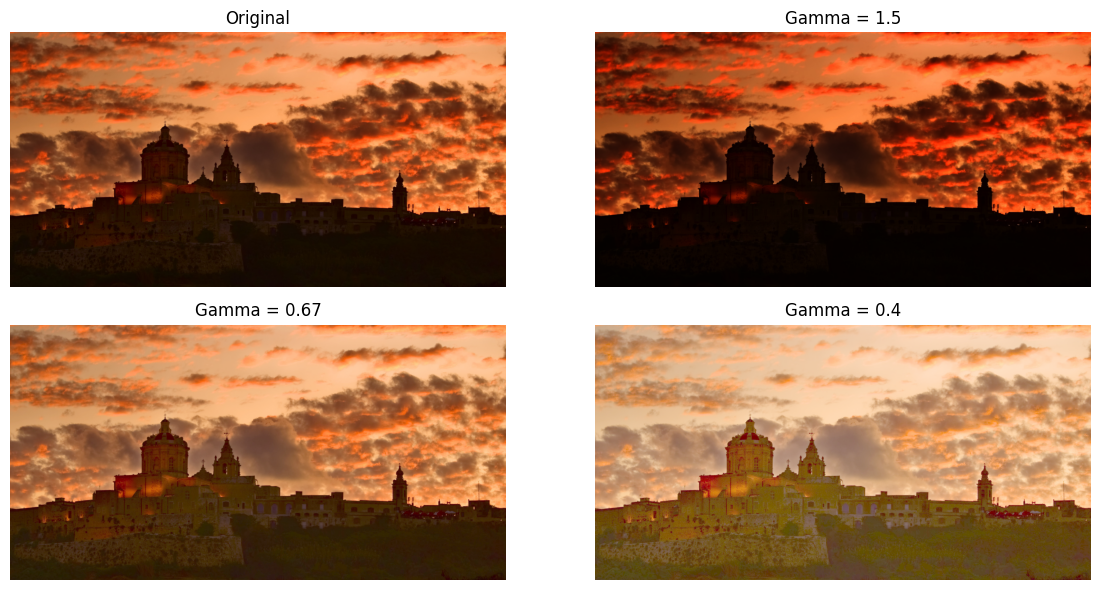

In [5]:
plot, axes = plt.subplots(2, 2, figsize=(12, 6))

axes[0, 0].imshow(img)
axes[0, 0].set_title('Original')
axes[0, 0].axis('off')

axes[0, 1].imshow(powerLaw(img, gamma=1.5))
axes[0, 1].set_title('Gamma = 1.5')
axes[0, 1].axis('off')

axes[1, 0].imshow(powerLaw(img, gamma=0.67))
axes[1, 0].set_title('Gamma = 0.67')
axes[1, 0].axis('off')

axes[1, 1].imshow(powerLaw(img, gamma=0.4))
axes[1, 1].set_title('Gamma = 0.4')
axes[1, 1].axis('off')

plot.tight_layout()

## Tone Mapping Operators

bla bla bla

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..49.0].


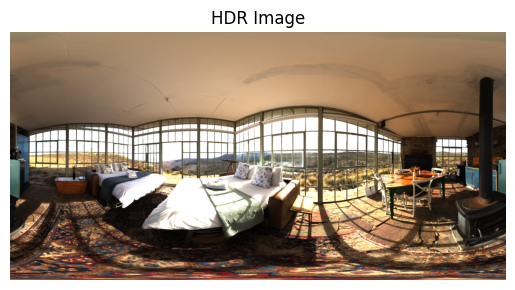

In [50]:
# Import HDR Image
# https://polyhaven.com/a/glasshouse_interior
hdr_img = cv2.imread('hdr_input.hdr', -1)
hdr_img = cv2.cvtColor(hdr_img, cv2.COLOR_BGR2RGB) # type: ignore
plt.imshow(hdr_img)
plt.title('HDR Image')
plt.axis('off')
plt.show()

### Reinhard Operator

bla bla bla

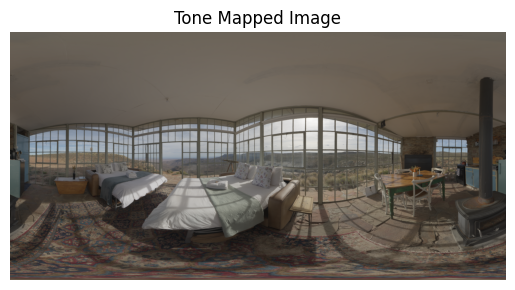

In [ ]:
# 2. Create the Reinhard Tonemapper
# intensity: default 0 (logarithmic average)
# light_adaptation: 0 to 1 (usually 0)
# color_adaptation: 0 to 1 (usually 0)
tonemap = cv2.createTonemapReinhard(intensity=0, light_adapt=0, color_adapt=0)

# 3. Apply tone mapping
ldr_img = tonemap.process(hdr_img) # type: ignore

# 4. Optional: Gamma correction (Standard monitors expect 2.2)
ldr_img = np.clip(ldr_img, 0, 1)
ldr_img = np.power(ldr_img, 1.0/2.2)

# 5. Convert to 8-bit for saving/viewing
ldr_8bit = (ldr_img * 255).astype(np.uint8)
plt.imshow(ldr_8bit)
plt.title('Tone Mapped Image')
plt.axis('off')
plt.show()

In [54]:
hdr_dr = hdr_img.max() / (hdr_img[hdr_img > 0].min())
ldr_dr = ldr_8bit.max() / (ldr_8bit[ldr_8bit > 0].min())

print("HDR Dynamic Range:", hdr_dr)
print("LDR Dynamic Range:", ldr_dr)

HDR Dynamic Range: 13607.051
LDR Dynamic Range: 25.5


### Hable Operator
bla bla bla

In [ ]:
def hable_operator(x):
    # These constants define the shape of the filmic curve
    A = 0.15 # Shoulder Strength
    B = 0.50 # Linear Strength
    C = 0.10 # Linear Angle
    D = 0.20 # Toe Strength
    E = 0.02 # Toe Enumerator
    F = 0.30 # Toe Denominator
    # Equation: ((x*(A*x+C*B)+D*E)/(x*(A*x+B)+D*F))-E/F
    return ((x * (A * x + C * B) + D * E) / (x * (A * x + B) + D * F)) - E / F

def apply_hable(hdr_img, exposure=2.0, white_point=11.2):
    # 1. Exposure Bias (Prep the HDR data)
    x = hdr_img * exposure
    
    # 2. Apply the curve to the image
    curr = hable_operator(x)
    
    # 3. Apply the curve to the white point for normalization
    # This ensures that the brightest possible value maps to 1.0
    white_scale = 1.0 / hable_operator(white_point)
    
    # 4. Final output
    ldr = curr * white_scale
    return np.clip(ldr, 0, 1)

# Usage
ldr_result = apply_hable(hdr_img)

# Gamma correction for your monitor
ldr_corrected = np.power(ldr_result, 1.0/2.2)

ldr_corrected_8bit = (ldr_corrected * 255).astype(np.uint8)

True

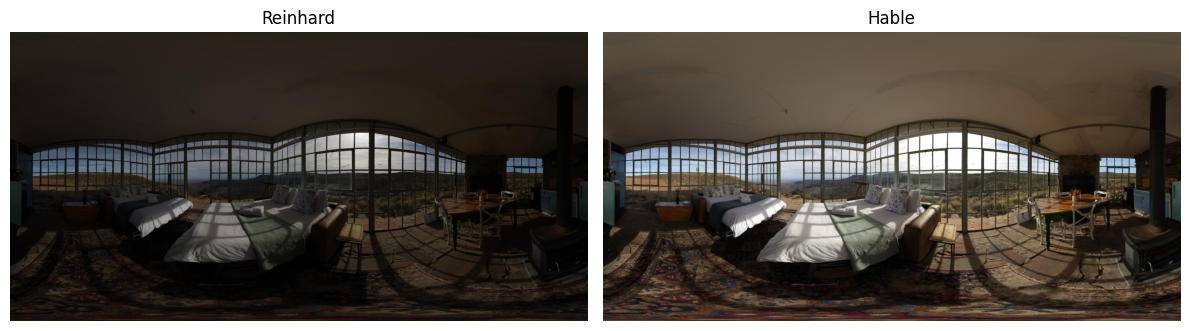

In [47]:
plot, axes = plt.subplots(1, 2, figsize=(12, 6))

reinhard_img = cv2.imread('reinhard_output.jpg')
reinhard_img = cv2.cvtColor(reinhard_img, cv2.COLOR_BGR2RGB) # type: ignore
hable_img = cv2.imread('hable_output.jpg')
hable_img = cv2.cvtColor(hable_img, cv2.COLOR_BGR2RGB) # type: ignore

axes[0].imshow(reinhard_img)
axes[0].set_title('Reinhard')
axes[0].axis('off')

axes[1].imshow(hable_img)
axes[1].set_title('Hable')
axes[1].axis('off')

plot.tight_layout()